In [5]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\Jagdish singh\\AppData\\Roaming\\Python\\Python313\\site-packages\\tensorflow\\python\\ops\\gen_control_flow_ops.py'
Check the permissions.



In [6]:
import tensorflow as tf 
print("tensorflow version se ",tf.__version__)

tensorflow version se  2.21.0


In [7]:
mnist=tf.keras.datasets.mnist

In [8]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [9]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [10]:
x_train[5998]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 105, 253,  65,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 148, 224,  14,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 150, 245, 159,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 211, 253,  63,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [11]:
x_train[0][1]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8)

In [12]:
import sys
print(sys.executable)

c:\python313\python.exe


In [13]:
import sys
!"{sys.executable}" -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


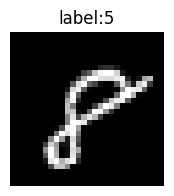

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))
plt.imshow(x_train[59999], cmap='gray')   # gray is standard spelling
plt.axis('off')   
plt.title("label:{}".format(y_train[0]))
plt.show()

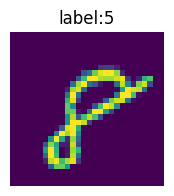

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))
plt.imshow(x_train[59999])   # gray without it  heatmap
plt.axis('off')   
plt.title("label:{}".format(y_train[0]))
plt.show()

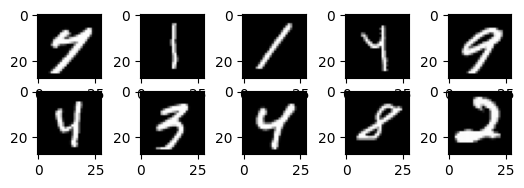

In [16]:
for i in range(1,11):
    plt.subplot(5,5,i)
    plt.imshow(x_train[i+1000],cmap='grey')
    
plt.show()

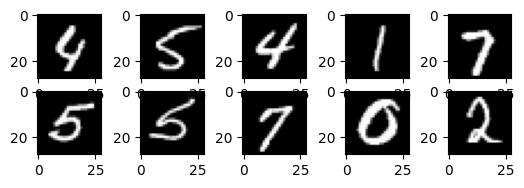

In [17]:
import random
import numpy as np

for i in range(1,11):
    plt.subplot(5,5,i)
    index=np.random.randint(0,59999)
    plt.imshow(x_train[index],cmap='grey')
    
plt.show()
# using np.random.randit to genrte random numbers for visualization


In [18]:
x_train=x_train/255.0
x_test=x_test/255.0

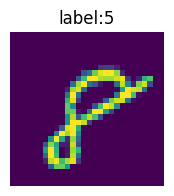

In [19]:
plt.figure(figsize=(2,2))
plt.imshow(x_train[59999])   # after scaling/normlizing data the image quality effects
plt.axis('off')   
plt.title("label:{}".format(y_train[0]))
plt.show()

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras import Input

In [21]:
# Sequential: Container to build neural network layer-by-layer in a linear stack.
# Input: Defines the shape/size of data entering the model.
# Flatten: Converts multi-dimensional input (e.g., 28x28 image) into a 1D vector.
# Dense: Fully connected layer where neurons learn patterns using weights and activation functions.

In [22]:
model=Sequential()
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [23]:
'''A Dense layer is a type of layer where:
every neuron connects to all neurons in the previous layer
(fully connected layer).

#  hidden layer is any layer between input and output of a neural network.'''

'A Dense layer is a type of layer where:\nevery neuron connects to all neurons in the previous layer\n(fully connected layer).\n\n#  hidden layer is any layer between input and output of a neural network.'

In [24]:
# Binary Classification: sigmoid  //same like log regression
# Multi-class Classification: softmax  //same like mutlinomail log regresion
# Regression: linear

##  Each layer has a different job, so it needs a different activation behavior.

In [25]:
#  compiling fit the engine optimize it and reduce fuel loss
model.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])


In [26]:
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9343 - loss: 0.2233 - val_accuracy: 0.9617 - val_loss: 0.1203
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9708 - loss: 0.0925 - val_accuracy: 0.9704 - val_loss: 0.0899
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9802 - loss: 0.0636 - val_accuracy: 0.9761 - val_loss: 0.0754
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9843 - loss: 0.0494 - val_accuracy: 0.9709 - val_loss: 0.0944
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9875 - loss: 0.0380 - val_accuracy: 0.9736 - val_loss: 0.0950
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9894 - loss: 0.0322 - val_accuracy: 0.9771 - val_loss: 0.0800
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9911 - loss: 0.0275 - val_accuracy: 0.9773 - val_loss: 0.0841
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9926 - loss: 0.0231 - 